In [ ]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp


## Produce similation dataset based on RK45

In [ ]:


def run_simulations(
    STARTTIME=0.0,
    STOPTIME=480.0,
    n_timepoints=600,
    step=0.01,
    positive_only=True,
    output_csv="bioreactor_dataset_RK45.csv"
):

    t_eval = np.linspace(STARTTIME, STOPTIME, n_timepoints)
    all_data = []

    # Sweep values
    if positive_only:
        values = np.arange(step, 1.01, step)
    else:
        values = np.arange(0.0, 1.01, step)

    values = np.round(values, 2)

    sim = 0

    for X in values:
        for feed_rate in values:

            sim += 1

            # =========================
            # Random parameters
            # =========================
            vmax = np.random.uniform(0.001, 0.2)
            Ks   = np.random.uniform(0.01, 10)
            k0   = np.random.uniform(0.01, 10)
            k1   = np.random.uniform(0.01, 10)
            k2   = np.random.uniform(0.01, 10)

            F1 = feed_rate * X

            # =========================
            # ODE system
            # =========================
            def odes(t, y):
                S, B, P = y

                kP = (
                    vmax * S
                    / (Ks * (1.0 + B / k1) + S + (S**2) / k0)
                    / (1.0 + P / k2)
                    * X
                )

                # Side reaction
                kB = 0.002 * S / (7.420 + S) * X

                dS = F1 - kB - kP
                dB = kB
                dP = kP

                return [dS, dB, dP]

            y0 = [0.0, 0.0, 0.0]

            sol = solve_ivp(
                odes,
                (STARTTIME, STOPTIME),
                y0,
                method="RK45",
                t_eval=t_eval,
                rtol=1e-6,
                atol=1e-9
            )

            # =========================
            # Store results
            # =========================
            for i in range(len(sol.t)):
                all_data.append([
                    sim,
                    sol.t[i],
                    sol.y[0, i],
                    sol.y[1, i],
                    sol.y[2, i],
                    X,
                    feed_rate,
                    F1,
                    vmax,
                    Ks,
                    k0,
                    k1,
                    k2
                ])

    # =========================
    # Save dataset
    # =========================
    columns = [
        "sim_id", "time_min", "S", "B", "P",
        "X", "feed_rate", "F1",
        "vmax", "Ks", "k0", "k1", "k2"
    ]

    dataset = pd.DataFrame(all_data, columns=columns)
    dataset.to_csv(output_csv, index=False)

    print(f"Dataset generated: {output_csv}")
    print(f"Total simulations: {sim}")

    return dataset


In [ ]:
dataset = run_simulations()


print(dataset.head())



Dataset generated: bioreactor_dataset_RK45.csv
Total simulations: 10000
   sim_id  time_min        S             B             P     X  feed_rate  \
0       1  0.000000  0.00000  0.000000e+00  0.000000e+00  0.01       0.01   
1       1  0.801336  0.00008  8.651973e-11  2.942228e-08  0.01       0.01   
2       1  1.602671  0.00016  3.459915e-10  1.176490e-07  0.01       0.01   
3       1  2.404007  0.00024  7.782842e-10  2.646202e-07  0.01       0.01   
4       1  3.205342  0.00032  1.383267e-09  4.702759e-07  0.01       0.01   

       F1      vmax        Ks        k0        k1        k2  
0  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
1  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
2  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
3  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
4  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  


In [ ]:
print(dataset.head())
print(dataset.tail())


   sim_id  time_min        S             B             P     X  feed_rate  \
0       1  0.000000  0.00000  0.000000e+00  0.000000e+00  0.01       0.01   
1       1  0.801336  0.00008  8.651973e-11  2.942228e-08  0.01       0.01   
2       1  1.602671  0.00016  3.459915e-10  1.176490e-07  0.01       0.01   
3       1  2.404007  0.00024  7.782842e-10  2.646202e-07  0.01       0.01   
4       1  3.205342  0.00032  1.383267e-09  4.702759e-07  0.01       0.01   

       F1      vmax        Ks        k0        k1        k2  
0  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
1  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
2  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
3  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
4  0.0001  0.051449  0.561246  9.448065  8.597403  7.106166  
         sim_id    time_min           S         B         P    X  feed_rate  \
5999995   10000  476.794658  475.789134  0.891436  0.114087  1.0        1.0   
5999996

In [ ]:
# ==========================================
# TinyMLP: (TIME, params) -> (S, B, P)
# With per-output evaluation metrics
# ==========================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------
# Load data
# --------------------------
data = dataset

# --------------------------
# Train / test split by trajectory
# --------------------------
sim_ids = data["sim_id"].unique()

train_sims, test_sims = train_test_split(
    sim_ids,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df = data[data["sim_id"].isin(train_sims)].reset_index(drop=True)
test_df  = data[data["sim_id"].isin(test_sims)].reset_index(drop=True)

# --------------------------
# Inputs / outputs (as requested)
# --------------------------
X_train = train_df[["time_min", "vmax", "Ks", "k0", "k1", "k2","X","feed_rate"]].values
Y_train = train_df[["S", "B", "P"]].values

X_test  = test_df[["time_min", "vmax", "Ks", "k0", "k1", "k2","X","feed_rate"]].values
Y_test  = test_df[["S", "B", "P"]].values

# --------------------------
# Normalize (train only)
# --------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_test  = y_scaler.transform(Y_test)

# --------------------------
# Torch tensors
# --------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

# --------------------------
# TinyMLP
# --------------------------
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

model = TinyMLP()

# --------------------------
# Training
# --------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 50
batch_size = 1024

for epoch in range(epochs):
    perm = torch.randperm(X_train.size(0))
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i + batch_size]
        optimizer.zero_grad()
        loss = loss_fn(model(X_train[idx]), Y_train[idx])
        loss.backward()
        optimizer.step()

# --------------------------
# Evaluation (TEST SET)
# --------------------------
model.eval()
with torch.no_grad():
    Y_pred_scaled = model(X_test).cpu().numpy()

# Inverse scaling
Y_pred = y_scaler.inverse_transform(Y_pred_scaled)
Y_true = y_scaler.inverse_transform(Y_test.cpu().numpy())

# --------------------------
# Metrics per variable
# --------------------------
labels = ["S", "B", "P"]

print("\nTest-set performance (trajectory-level split):\n")

for i, label in enumerate(labels):
    r2   = r2_score(Y_true[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_true[:, i], Y_pred[:, i]))
    mae  = mean_absolute_error(Y_true[:, i], Y_pred[:, i])

    print(f"{label}:")
    print(f"  R²   = {r2:.4f}")
    print(f"  RMSE = {rmse:.6f}")
    print(f"  MAE  = {mae:.6f}\n")

print("Evaluation complete.")



Test-set performance (trajectory-level split):

S:
  R²   = 0.9999
  RMSE = 0.796750
  MAE  = 0.610910

B:
  R²   = 0.9998
  RMSE = 0.002559
  MAE  = 0.001615

P:
  R²   = 0.9964
  RMSE = 0.086911
  MAE  = 0.033214

Evaluation complete.


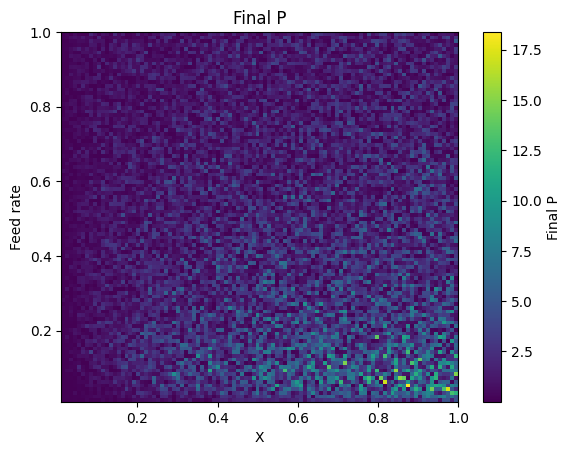

In [ ]:
import pandas as pd

summary = []

for (X, feed), df in dataset.groupby(["X", "feed_rate"]):
    summary.append({
        "X": X,
        "feed_rate": feed,
        "final_S": df["S"].iloc[-1],
        "final_B": df["B"].iloc[-1],
        "final_P": df["P"].iloc[-1],
    })

summary_df = pd.DataFrame(summary)
S_grid = summary_df.pivot(index="feed_rate", columns="X", values="final_S")
B_grid = summary_df.pivot(index="feed_rate", columns="X", values="final_B")
P_grid = summary_df.pivot(index="feed_rate", columns="X", values="final_P")
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(
    P_grid.values,
    origin="lower",
    aspect="auto",
    extent=[
        P_grid.columns.min(), P_grid.columns.max(),
        P_grid.index.min(), P_grid.index.max()
    ]
)

plt.xlabel("X")
plt.ylabel("Feed rate")
plt.title("Final P")

plt.colorbar(label="Final P")
plt.show()


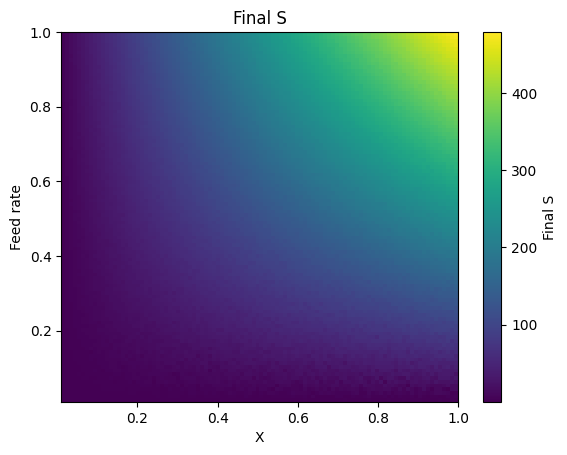

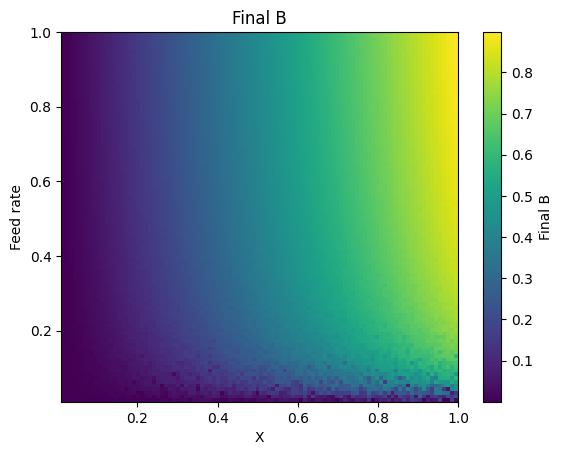

In [ ]:
# S
plt.figure()
plt.imshow(
    S_grid.values,
    origin="lower",
    aspect="auto",
    extent=[
        S_grid.columns.min(), S_grid.columns.max(),
        S_grid.index.min(), S_grid.index.max()
    ]
)
plt.xlabel("X")
plt.ylabel("Feed rate")
plt.title("Final S")
plt.colorbar(label="Final S")
plt.show()

# B
plt.figure()
plt.imshow(
    B_grid.values,
    origin="lower",
    aspect="auto",
    extent=[
        B_grid.columns.min(), B_grid.columns.max(),
        B_grid.index.min(), B_grid.index.max()
    ]
)
plt.xlabel("X")
plt.ylabel("Feed rate")
plt.title("Final B")
plt.colorbar(label="Final B")
plt.show()


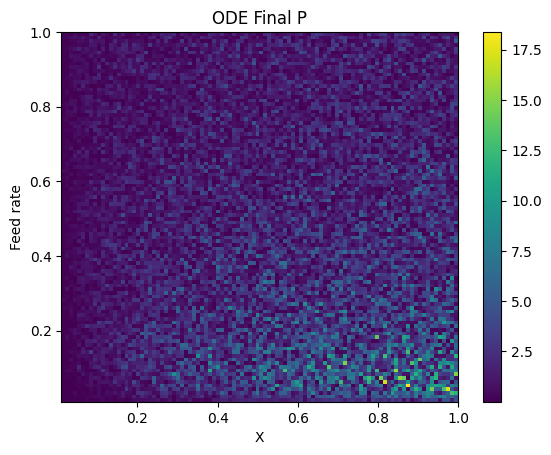

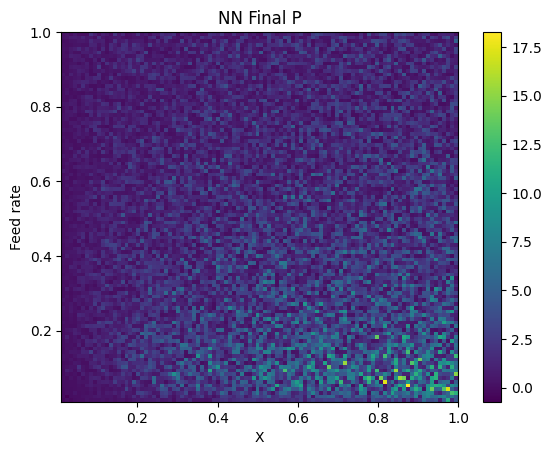

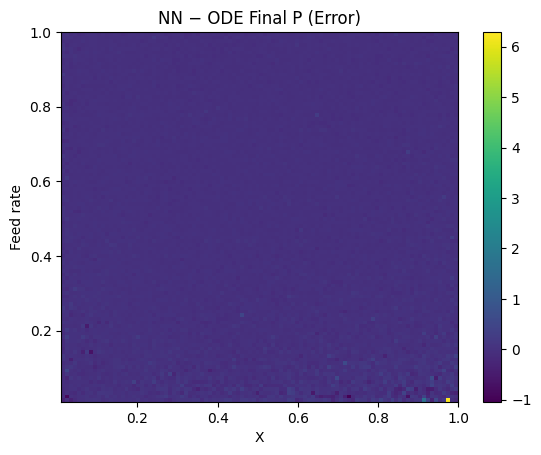

Surface RMSE:
S: 1.4144943500041884
B: 0.003713988278972575
P: 0.08780185579394288


In [ ]:
import matplotlib.pyplot as plt

# --------------------------
# NN predictions on full dataset
# --------------------------
model.eval()
with torch.no_grad():
    X_all = data[["time_min", "vmax", "Ks", "k0", "k1", "k2", "X", "feed_rate"]].values
    X_all = x_scaler.transform(X_all)
    X_all = torch.tensor(X_all, dtype=torch.float32)

    Y_all_scaled = model(X_all).cpu().numpy()
    Y_all = y_scaler.inverse_transform(Y_all_scaled)

data_cmp = data.copy()
data_cmp["S_nn"] = Y_all[:, 0]
data_cmp["B_nn"] = Y_all[:, 1]
data_cmp["P_nn"] = Y_all[:, 2]

# --------------------------
# Extract FINAL values per (X, feed_rate)
# --------------------------
rows = []

for (X, feed), df in data_cmp.groupby(["X", "feed_rate"]):
    rows.append({
        "X": X,
        "feed_rate": feed,

        "S_ode": df["S"].iloc[-1],
        "B_ode": df["B"].iloc[-1],
        "P_ode": df["P"].iloc[-1],

        "S_nn": df["S_nn"].iloc[-1],
        "B_nn": df["B_nn"].iloc[-1],
        "P_nn": df["P_nn"].iloc[-1],
    })

final_df = pd.DataFrame(rows)

# --------------------------
# Build grids (X horizontal, feed vertical)
# --------------------------
S_ode = final_df.pivot(index="feed_rate", columns="X", values="S_ode")
B_ode = final_df.pivot(index="feed_rate", columns="X", values="B_ode")
P_ode = final_df.pivot(index="feed_rate", columns="X", values="P_ode")

S_nn = final_df.pivot(index="feed_rate", columns="X", values="S_nn")
B_nn = final_df.pivot(index="feed_rate", columns="X", values="B_nn")
P_nn = final_df.pivot(index="feed_rate", columns="X", values="P_nn")

S_err = S_nn - S_ode
B_err = B_nn - B_ode
P_err = P_nn - P_ode

# --------------------------
# Plot helper
# --------------------------
def plot_surface(Z, title):
    plt.figure()
    plt.imshow(
        Z.values,
        origin="lower",
        aspect="auto",
        extent=[
            Z.columns.min(), Z.columns.max(),
            Z.index.min(), Z.index.max()
        ]
    )
    plt.xlabel("X")
    plt.ylabel("Feed rate")
    plt.title(title)
    plt.colorbar()
    plt.show()

# --------------------------
# Plots (P shown; repeat for S/B if desired)
# --------------------------
plot_surface(P_ode, "ODE Final P")
plot_surface(P_nn,  "NN Final P")
plot_surface(P_err, "NN − ODE Final P (Error)")

# --------------------------
# Quantitative surface RMSE
# --------------------------
print("Surface RMSE:")
print("S:", np.sqrt(np.mean(S_err.values**2)))
print("B:", np.sqrt(np.mean(B_err.values**2)))
print("P:", np.sqrt(np.mean(P_err.values**2)))


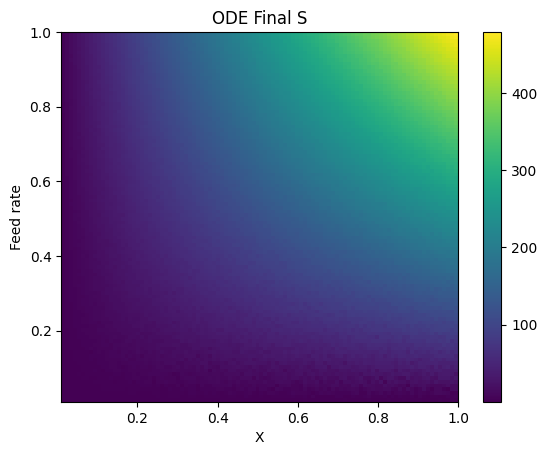

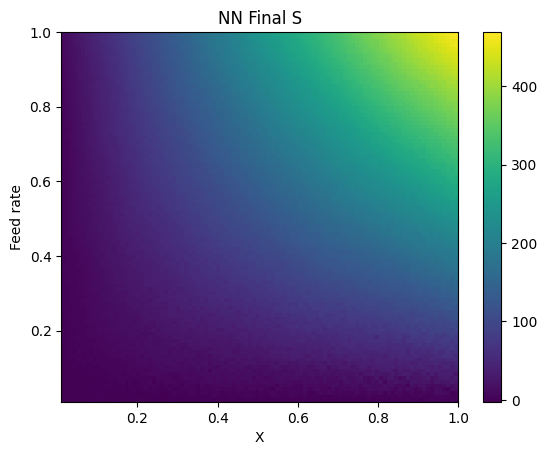

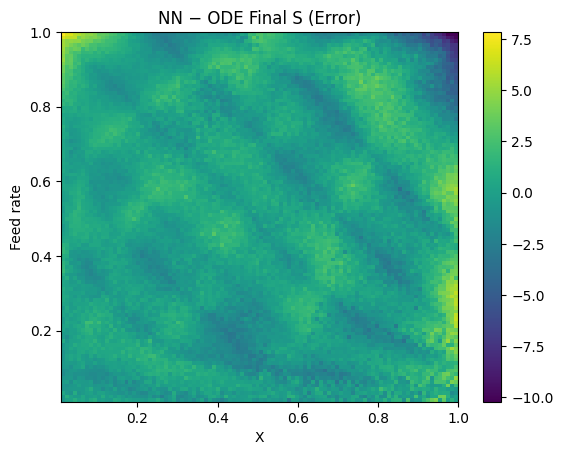

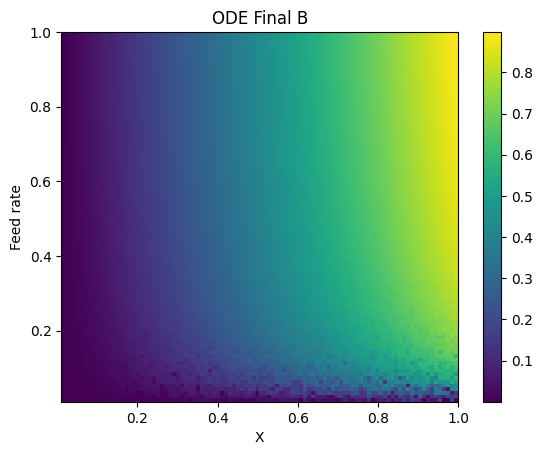

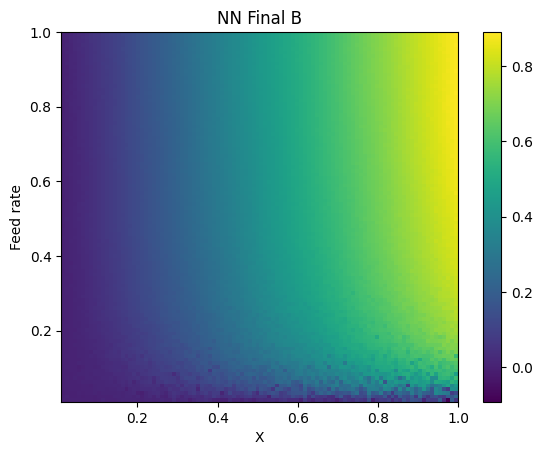

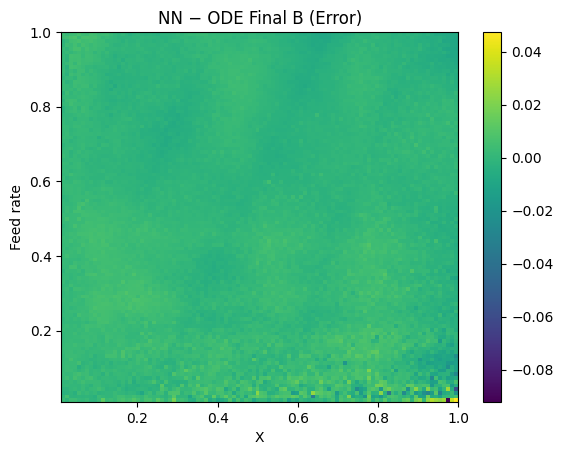

In [ ]:
# --------------------------
# Plots for S
# --------------------------
plot_surface(S_ode, "ODE Final S")
plot_surface(S_nn,  "NN Final S")
plot_surface(S_err, "NN − ODE Final S (Error)")

# --------------------------
# Plots for B
# --------------------------
plot_surface(B_ode, "ODE Final B")
plot_surface(B_nn,  "NN Final B")
plot_surface(B_err, "NN − ODE Final B (Error)")


## optimize paramethers:

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin

class NNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, vmax=0.1, Ks=1.0, k0=1.0, k1=1.0, k2=1.0, X=0.5, feed_rate=0.5):
        self.vmax = vmax
        self.Ks = Ks
        self.k0 = k0
        self.k1 = k1
        self.k2 = k2
        self.X = X
        self.feed_rate = feed_rate

    def fit(self, X=None, y=None):
        return self  # NN already trained

    def score(self, X=None, y=None):
        # final time fixed
        X_nn = np.array([[480.0,
                          self.vmax,
                          self.Ks,
                          self.k0,
                          self.k1,
                          self.k2,
                          self.X,
                          self.feed_rate]])

        X_nn = x_scaler.transform(X_nn)

        with torch.no_grad():
            y_scaled = model(torch.tensor(X_nn, dtype=torch.float32)).numpy()

        P = y_scaler.inverse_transform(y_scaled)[0, 2]

        return P   # maximize P


    
    


In [ ]:
search_space = {
    "vmax": Real(0.001, 0.2),
    "Ks": Real(0.01, 10),
    "k0": Real(0.01, 10),
    "k1": Real(0.01, 10),
    "k2": Real(0.01, 10),
    "X": Real(0.1, 1.0),
    "feed_rate": Real(0.1, 1.0),
}
from skopt import BayesSearchCV

X_dummy = np.zeros((20,1))
y_dummy = np.zeros((20,1))

opt = BayesSearchCV(
    NNWrapper(),
    search_space,
    n_iter=40,
    random_state=0
)

opt.fit(X_dummy, y_dummy)

print("Best params:")
print(opt.best_params_)

print("Predicted max P:")
print(opt.best_score_)



NameError: name 'Real' is not defined

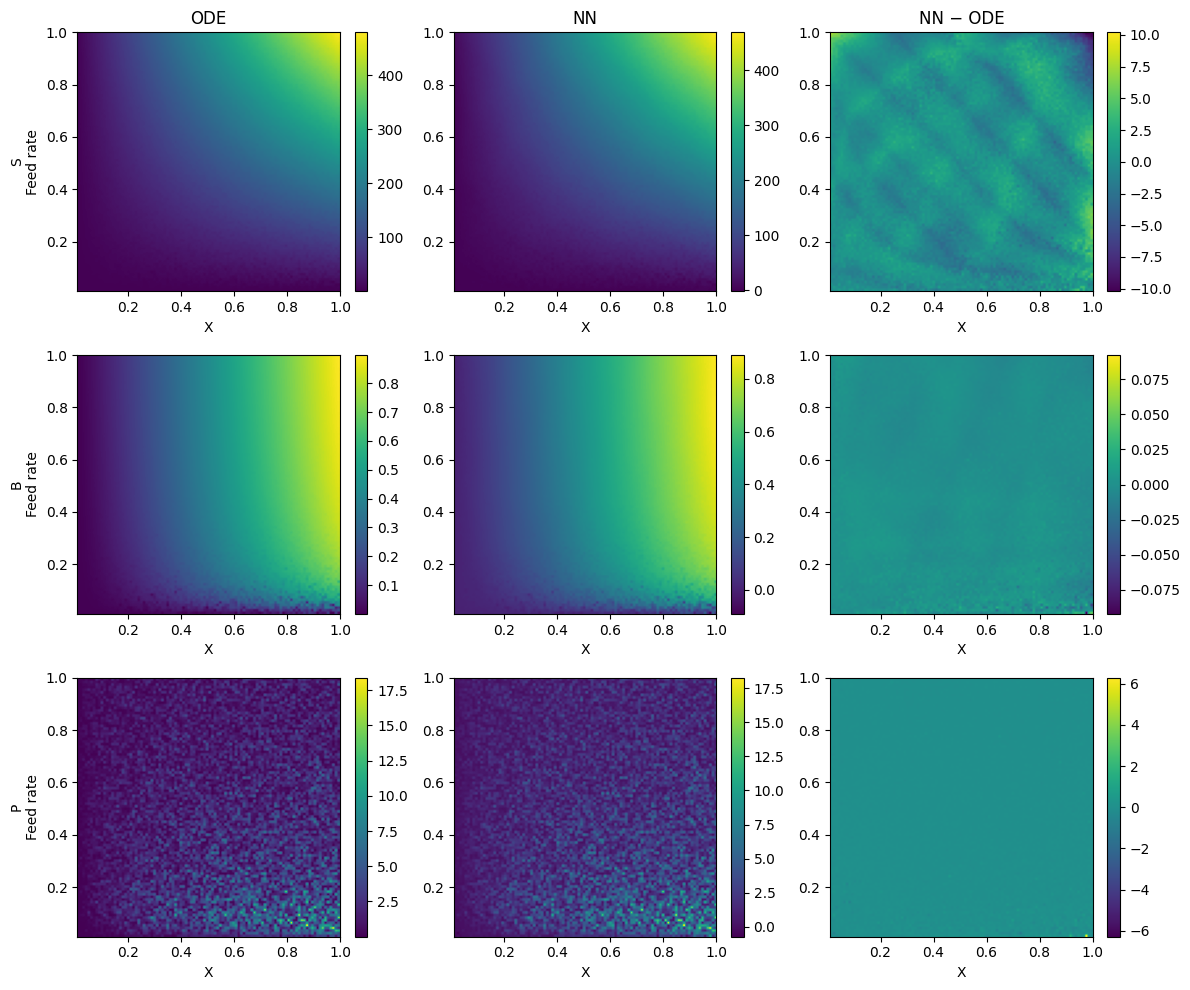

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

surfaces = [
    (S_ode, S_nn, S_err, "S"),
    (B_ode, B_nn, B_err, "B"),
    (P_ode, P_nn, P_err, "P"),
]

titles = ["ODE", "NN", "NN − ODE"]

for r, (ode, nn, err, label) in enumerate(surfaces):

    vmax_err = np.max(np.abs(err.values))

    for c, Z in enumerate([ode, nn, err]):

        ax = axes[r, c]

        if c == 2:
            im = ax.imshow(
                Z.values,
                origin="lower",
                aspect="auto",
                vmin=-vmax_err,
                vmax=vmax_err,
                extent=[
                    Z.columns.min(), Z.columns.max(),
                    Z.index.min(), Z.index.max()
                ]
            )
        else:
            im = ax.imshow(
                Z.values,
                origin="lower",
                aspect="auto",
                extent=[
                    Z.columns.min(), Z.columns.max(),
                    Z.index.min(), Z.index.max()
                ]
            )

        if r == 0:
            ax.set_title(titles[c])

        if c == 0:
            ax.set_ylabel(f"{label}\nFeed rate")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("X")

        fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.integrate import solve_ivp

class ODEWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, vmax=0.1, Ks=1.0, k0=1.0, k1=1.0, k2=1.0, X=0.5, feed_rate=0.5):
        self.vmax = vmax
        self.Ks = Ks
        self.k0 = k0
        self.k1 = k1
        self.k2 = k2
        self.X = X
        self.feed_rate = feed_rate

    def fit(self, X=None, y=None):
        return self   # nothing to train

    def score(self, X=None, y=None):
        # Fixed horizon
        STARTTIME = 0.0
        STOPTIME = 480.0

        F1 = self.feed_rate * self.X

        def odes(t, y):
            S, B, P = y

            kP = (
                self.vmax * S
                / (self.Ks * (1.0 + B / self.k1) + S + (S**2) / self.k0)
                / (1.0 + P / self.k2)
                * self.X
            )

            kB = 0.002 * S / (7.420 + S) * self.X

            dS = F1 - kB - kP
            dB = kB
            dP = kP

            return [dS, dB, dP]

        y0 = [0.0, 0.0, 0.0]

        sol = solve_ivp(
            odes,
            (STARTTIME, STOPTIME),
            y0,
            method="RK45",
            t_eval=[STOPTIME],   # ONLY final time
            rtol=1e-6,
            atol=1e-9
        )

        # Final P
        P_final = sol.y[2, -1]

        return P_final   # BayesSearchCV maximizes score
from skopt.space import Real

search_space = {
    "vmax": Real(0.001, 0.2),
    "Ks": Real(0.01, 10),
    "k0": Real(0.01, 10),
    "k1": Real(0.01, 10),
    "k2": Real(0.01, 10),
    "X": Real(0.1, 1.0),
    "feed_rate": Real(0.1, 1.0),
}
from skopt import BayesSearchCV
import numpy as np

X_dummy = np.zeros((10,1))
y_dummy = np.zeros((10,1))

opt_ode = BayesSearchCV(
    ODEWrapper(),
    search_space,
    n_iter=25,      # ODE is slow
    random_state=0
)

opt_ode.fit(X_dummy, y_dummy)
print("Best ODE parameters:")
print(opt_ode.best_params_)

print("Maximum final P (ODE):")
print(opt_ode.best_score_)





Best ODE parameters:
OrderedDict([('Ks', 0.01), ('X', 0.8418749368062222), ('feed_rate', 0.1), ('k0', 7.5072793484749285), ('k1', 0.01), ('k2', 4.637633021238089), ('vmax', 0.2)])
Maximum final P (ODE):
15.914900941089916
